# Step 6 - End-to-end workflow (capstone)

**Goal:** tie steps 1 through 5 together on the packaged `dummy_data.csv`.

Workflow:
1. **Split** the series around the intervention (step 1).
2. **Sanity-check** the CV fold layout (step 2), making sure no fold touches the evaluation window.
3. **Tune** `prophet_xgb` via `tune_model()` on a small budget (step 3).
4. **Fit** the final model via `run_single_its()` using the tuned `best_params` (step 4).
5. **Inspect** the MBB CI fan (step 5) alongside the ATE summary.
6. **Compare** against ARIMA with `compare_models()`.

Every stochastic step carries an explicit seed (LHS, MBB, model RNG) so the run is reproducible.


In [1]:
%matplotlib inline

import logging
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.WARNING)

from its2s import run_single_its, tune_model, compare_models, time_series_cv

OUT_DIR = Path.cwd() / 'figures'
OUT_DIR.mkdir(exist_ok=True)

DATA = Path('data/dummy_data.csv')
INTERVENTION = pd.Timestamp('2022-03-15')
TEST_DAYS = 90
HOLDOUT_DAYS = 42

df = pd.read_csv(DATA, parse_dates=['ds']).sort_values('ds').reset_index(drop=True)
print(f'n={len(df)} rows, {df.ds.min().date()} -> {df.ds.max().date()}')
print(f'intervention={INTERVENTION.date()} (eval window = prior {TEST_DAYS} days)')


n=1576 rows, 2018-01-01 -> 2022-04-25
intervention=2022-03-15 (eval window = prior 90 days)


## 6a. Split + CV sanity check

Confirm that no CV fold test window touches the `run_single_its` evaluation window `[intervention - test_days, intervention)`.


In [2]:
cv_end = INTERVENTION - pd.Timedelta(days=TEST_DAYS)
cv_result = time_series_cv(
    df=df,
    intervention_date=INTERVENTION,
    model_name='arima',
    n_folds=3,
    test_days=90,
    min_train_days=365,
    skip_days=0,
    cv_end_date=cv_end,
)
last_fold_end = max(f.test_end for f in cv_result.folds)
assert last_fold_end < cv_end, 'CV fold leaked into evaluation window!'
print(cv_result.summary())
print(f'\nlast CV fold ends:   {last_fold_end.date()}')
print(f'cv_end_date:         {cv_end.date()}')
print(f'intervention_date:   {INTERVENTION.date()}')
print('-> No leakage.')


Cross-validation: arima (3 folds)
  RMSE: 8.1242 +/- 2.6749
  MAE:  6.9769 +/- 2.2092
  MAPE: 13.16%
  R2:   -4.2134

last CV fold ends:   2019-09-27
cv_end_date:         2021-12-15
intervention_date:   2022-03-15
-> No leakage.


## 6b. Tune `prophet_xgb` (small budget)

Small `n_trials` + `n_folds` keeps this notebook fast. For publication-grade tuning use `n_trials=100`, `n_folds=5`, `test_days=365`, `min_train_days=730`, `skip_days=365`.


In [3]:
tuning_result = tune_model(
    df=df,
    intervention_date=INTERVENTION,
    model_name='prophet_xgb',
    n_trials=8,
    n_folds=3,
    test_days=90,
    min_train_days=365,
    skip_days=0,
    cv_end_date=cv_end,
    metric='rmse',
    n_jobs=1,
    seed=42,
)
print(f'best CV RMSE: {tuning_result.best_rmse:.3f} +/- {tuning_result.best_std_rmse:.3f}')
print('best_params:'); display(tuning_result.best_params)


best CV RMSE: 2.002 +/- 0.129
best_params:


{'prophet': {'changepoint_prior_scale': 0.03501670294289283,
  'seasonality_prior_scale': 0.11011093513903454,
  'changepoint_range': 0.7312334311248594},
 'xgb': {'n_estimators': 145,
  'max_depth': 18,
  'learning_rate': 0.0011493513094884857,
  'min_child_weight': 5,
  'subsample': 0.8355835948034878,
  'colsample_bytree': 0.957344031001564,
  'gamma': 0.512401004717215}}

## 6c. Fit the final model with tuned params


In [4]:
from its2s.metrics.excess import calc_ate_summary

pr = run_single_its(
    df=df,
    intervention_date=INTERVENTION,
    model_name='prophet_xgb',
    config_overrides={
        'models': {'prophet_xgb': tuning_result.best_params},
        'bootstrap': {'n_sim': 200, 'block_length': 14},  # small n_sim for notebook speed
    },
)
ate = calc_ate_summary(pr.excess_table)
print('ATE summary:'); display(ate)
print('\ntest metrics:'); print(pr.metrics_test)
print('\nexcess (period):'); display(pr.excess_table.period_excess)


ATE summary:


,metric,estimate,ci_lo,ci_hi,n_days
0,Total ATE,316.553688,286.863343,339.336038,42
1,Mean Daily ATE,7.536993,6.830080,8.079429,42



test metrics:
MetricsResult(rmse=2.1260378504737143, mae=1.689394756216408, mape=3.283617757674704, smape=3.27301747434856, mase=0.7315248467580961, r2=0.8951798408202808)

excess (period):


,period,start_date,end_date,n_days,total_observed,total_expected,total_excess,excess_ci_lo,excess_ci_hi,excess_pct
0,Full holdout,2022-03-15,2022-04-25,42,3029.800778,2713.24709,316.553688,286.863343,339.336038,11.666969


## 6d. Plot the tuned counterfactual with MBB CI fan


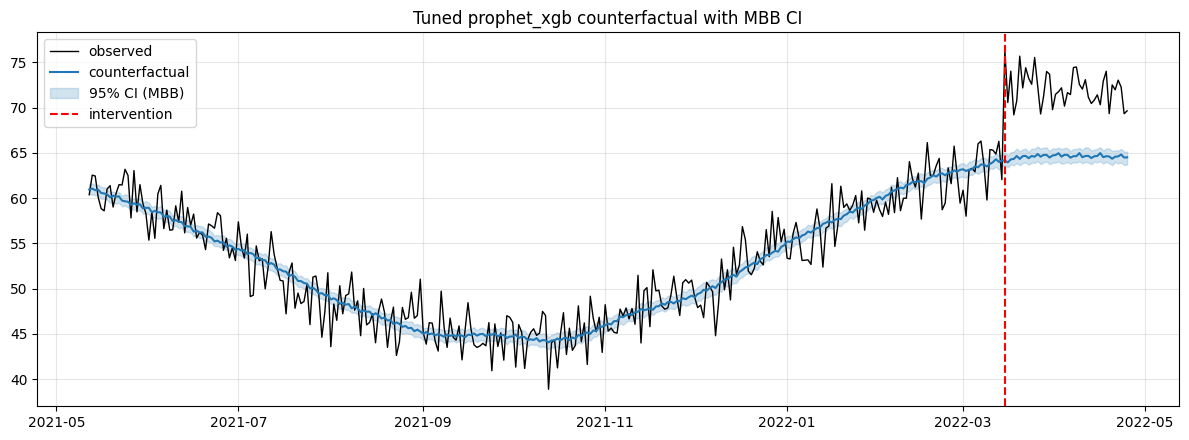

In [5]:
boot = pr.bootstrap_result

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(boot.dates, boot.actual, color='black', lw=1, label='observed')
ax.plot(boot.dates, boot.predicted, color='tab:blue', lw=1.5, label='counterfactual')
ax.fill_between(boot.dates, boot.conf_lo, boot.conf_hi, color='tab:blue', alpha=0.2, label='95% CI (MBB)')
ax.axvline(INTERVENTION, color='red', linestyle='--', label='intervention')
ax.set_title('Tuned prophet_xgb counterfactual with MBB CI')
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'step6_tuned_counterfactual.png', dpi=150)
display(fig)


## Key takeaways

1. **The pieces compose cleanly.** `prepare_splits` -> `time_series_cv` -> `tune_model` -> `run_single_its` -> MBB CI -> `compare_models`. No manual remapping between stages.
2. **Leakage-free tuning matters.** `cv_end_date = intervention - test_days` is the one-line fix that keeps step-3 tuning honest.
3. **Seeds are load-bearing.** LHS seed, bootstrap `random_state`, and any model-internal RNG must be set for results to be reproducible between sessions.
4. **The notebook uses small budgets for speed.** Production settings (`n_trials=100`, `n_sim=1000`, `n_folds=5`, `skip_days=365`) will give tighter and more trustworthy CIs at the cost of runtime.
